**LAB EXPERIMENT - 6**

**Implementation of Ensemble Techniques (Bagging, Boosting, Random Forest, Stacking) and Handling Class Imbalance (SMOTE)**

Name : Poovika M\
Roll No : 24BAD087

**SCENARIO 1**

**CODE INTERPRETATION**
1. Import Libraries

     Libraries are imported for:

    => Data handling (pandas, numpy)\
    => Model building (Decision Tree, BaggingClassifier)\
    => Evaluation (accuracy, confusion matrix)\
    => Visualization (matplotlib)

2. Load Dataset

    The diabetes dataset is loaded using:

    => read_csv()

3. Select Features & Target

    Input features:

    => Glucose, BMI, Age, Blood Pressure, etc.

    Target variable:

    => Outcome (0 = No Diabetes, 1 = Diabetes)

4. Train-Test Split

    Dataset is divided into:

    => 80% training data\
    => 20% testing data

5. Train Decision Tree Model

    A Decision Tree classifier is trained using training data.

    Predictions are made on test data and accuracy is calculated.

6. Apply Bagging Classifier

    BaggingClassifier is applied with:

    => Decision Tree as base estimator\
    => n_estimators = 50

    Model is trained and predictions are made.

7. Compare Accuracy

    Accuracy of both models is compared:

    => Decision Tree Accuracy\
    => Bagging Accuracy

8. Visualization

    => Bar graph is plotted to compare model accuracy
    => Confusion matrix is plotted for Bagging model

**CONCLUSION**

The program applies Bagging to improve the performance of a Decision Tree model. Bagging combines multiple models to reduce overfitting and improve accuracy. The results show that Bagging provides better performance compared to a single Decision Tree.

POOVIKA M - 24BAD087

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


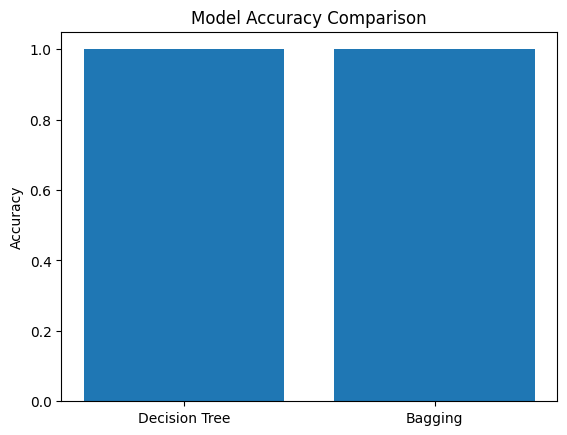

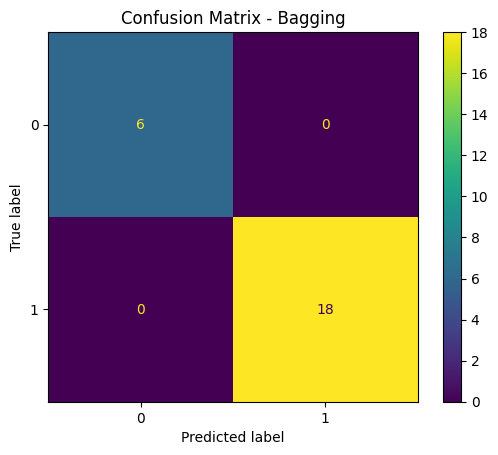

In [1]:
#POOVIKA M - 24BAD087
#EXP_9 - SCENARIO_1

print("POOVIKA M - 24BAD087\n")
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#Load dataset
df = pd.read_csv("/content/sample_data/diabetes_bagging.csv")

#Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

#Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Decision Tree Model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

#Bagging Classifier
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)
bag_accuracy = accuracy_score(y_test, y_pred_bag)

#Print Accuracy
print("Decision Tree Accuracy:", dt_accuracy)
print("Bagging Accuracy:", bag_accuracy)

#Visualization - Accuracy Comparison
models = ["Decision Tree", "Bagging"]
accuracies = [dt_accuracy, bag_accuracy]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

#Confusion Matrix (Bagging)
cm = confusion_matrix(y_test, y_pred_bag)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Bagging")
plt.show()

**SCENARIO 2**

**CODE INTERPRETATION**
1. Import Libraries

   Libraries are imported for:

    => Data handling (pandas)\
    => Model building (AdaBoost, Gradient Boosting)\
    => Preprocessing (LabelEncoder)\
    => Evaluation (accuracy, ROC, AUC)\
    => Visualization (matplotlib)

2. Load Dataset

    The churn dataset is loaded using:

    => read_csv()

    Column names are checked using:

    => columns

3. Data Preprocessing

    => customerID column is removed\
    => TotalCharges is converted to numeric\
    => Missing values are removed\
    => Categorical variables are encoded using LabelEncoder

4. Select Features & Target

    Input features:

    => Tenure, Monthly Charges, Contract Type, etc.

    Target variable:

    => Churn (Yes/No)

5. Train-Test Split

    Dataset is divided into:

    => 80% training data\
    => 20% testing data

6. Train AdaBoost Model

    => AdaBoost classifier is trained with n_estimators = 50\
    => Predictions and probabilities are generated\
    => Accuracy is calculated

7. Train Gradient Boosting Model

    => Gradient Boosting classifier is trained with n_estimators = 100\
    => Predictions and probabilities are generated\
    => Accuracy is calculated

8. Compare Performance

    => Accuracy of AdaBoost and Gradient Boosting is compared

9. ROC Curve

    => ROC curve is plotted for both models\
    => AUC score is calculated\
    => Helps evaluate classification performance

10. Feature Importance

    => Feature importance is extracted from Gradient Boosting
    => Bar chart is plotted to show important features

**CONCLUSION**

The program applies boosting techniques (AdaBoost and Gradient Boosting) to predict customer churn. Both models improve performance by combining multiple learners. Their performance is compared using accuracy and ROC curve, and important features influencing churn are identified.

POOVIKA M - 24BAD087

Columns in dataset:
 Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')

AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


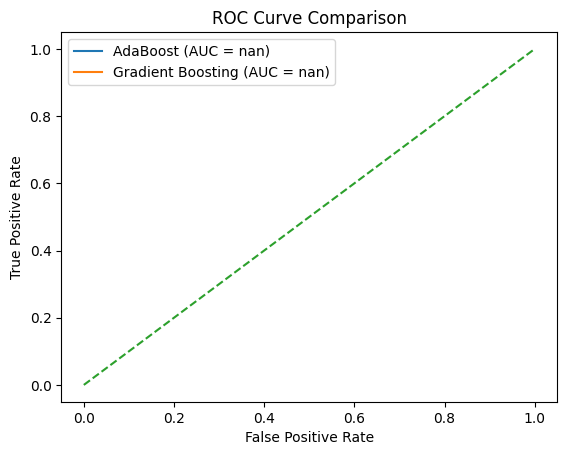

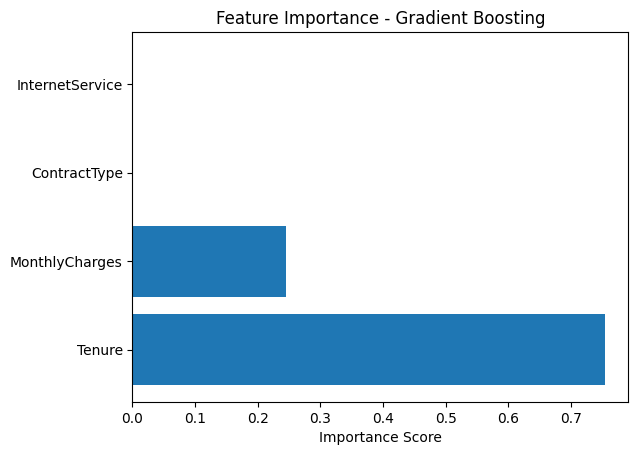

In [2]:
#POOVIKA M - 24BAD087
#EXP_9 - SCENARIO_2

print("POOVIKA M - 24BAD087\n")
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

#Load dataset
df = pd.read_csv("/content/sample_data/churn_boosting.csv")

#Check column names
print("Columns in dataset:\n", df.columns)

#Data Preprocessing

#Drop customerID if present
df.drop("customerID", axis=1, inplace=True, errors='ignore')
df.drop("CustomerID", axis=1, inplace=True, errors='ignore')

#Convert TotalCharges if present
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

#Remove missing values
df.dropna(inplace=True)

#Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

#Features and Target
#Try common target names
if "Churn" in df.columns:
    target_col = "Churn"
elif "churn" in df.columns:
    target_col = "churn"
else:
    raise Exception("Churn column not found in dataset")

X = df.drop(target_col, axis=1)
y = df[target_col]

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#AdaBoost Model
ada_model = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]

ada_acc = accuracy_score(y_test, y_pred_ada)

#Gradient Boosting Model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

gb_acc = accuracy_score(y_test, y_pred_gb)

#Print Results
print("\nAdaBoost Accuracy:", ada_acc)
print("Gradient Boosting Accuracy:", gb_acc)

#ROC Curve
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

roc_auc_ada = auc(fpr_ada, tpr_ada)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.plot(fpr_ada, tpr_ada, label="AdaBoost (AUC = %0.2f)" % roc_auc_ada)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC = %0.2f)" % roc_auc_gb)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

#Feature Importance (Gradient Boosting)
importances = gb_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.show()

**SCENARIO 3**

**CODE INTERPRETATION**
1. Import Libraries

   Libraries are imported for:

    => Data handling (pandas)\
    => Model building (Random Forest)\
    => Evaluation (accuracy)\
    => Visualization (matplotlib)

2. Load Dataset

    The income dataset is loaded using:

    => read_csv()

    Column names are checked using:

    => columns

3. Select Features & Target

    Input features:

    => Age, Education, Occupation, Hours-per-week

    Target variable:

    => Income (>50K or <=50K)

4. Train-Test Split

    Dataset is divided into:

    => 80% training data\
    => 20% testing data

5. Train Random Forest Model

    => Random Forest classifier is trained with n_estimators = 100\
    => Predictions are made on test data\
    => Accuracy is calculated

6. Tune Number of Trees

    => Different values of trees are tested (10, 50, 100, 150, 200)\
    => Accuracy is calculated for each model

7. Evaluate Model

    => Accuracy of the model is measured\
    => Performance is compared for different tree values

8. Visualization

    => Accuracy vs Number of Trees graph is plotted\
    => Feature importance graph is plotted

**CONCLUSION**

The program applies Random Forest to predict income category. It improves performance by combining multiple decision trees. The effect of number of trees is analyzed, and important features influencing income are identified.

POOVIKA M - 24BAD087

Columns:
 Index(['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income'], dtype='object')

Default Random Forest Accuracy: 1.0


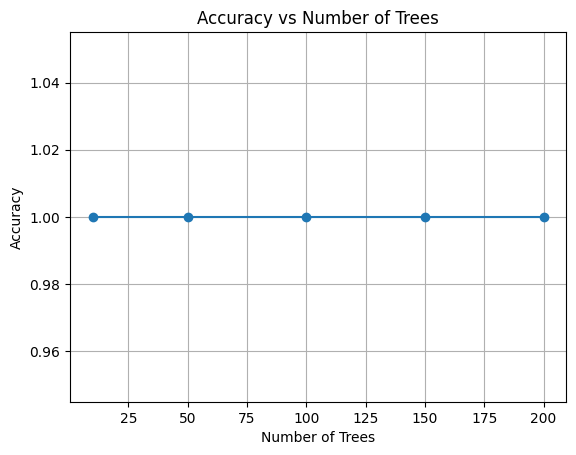

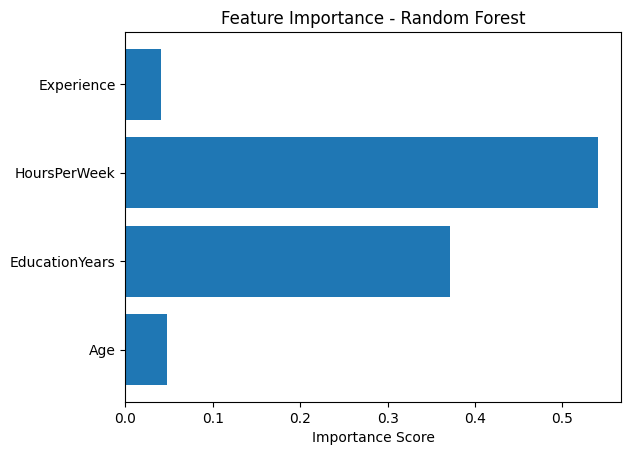

In [3]:
#POOVIKA M - 24BAD087
#EXP_9 - SCENARIO_3

print("POOVIKA M - 24BAD087\n")
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Load dataset
df = pd.read_csv("/content/sample_data/income_random_forest.csv")

#Check columns
print("Columns:\n", df.columns)

#Features & Target
target_col = "Income"

X = df.drop(target_col, axis=1)
y = df[target_col]

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train Random Forest (default)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc_default = accuracy_score(y_test, y_pred)

print("\nDefault Random Forest Accuracy:", acc_default)

#Tune Number of Trees
trees = [10, 50, 100, 150, 200]
accuracies = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

#Accuracy vs Number of Trees Graph
plt.figure()
plt.plot(trees, accuracies, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

#Feature Importance
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

**SCENARIO 4**

**CODE INTERPRETATION**
1. Import Libraries

     Libraries are imported for:

    => Data handling (pandas)\
    => Preprocessing (LabelEncoder, StandardScaler)\
    => Model building (Logistic Regression, SVM, Decision Tree, Stacking)\
    => Evaluation (accuracy)\
    => Visualization (matplotlib)

2. Load Dataset

    The heart disease dataset is loaded using:

    => read_csv()

    Column names are checked using:

    => columns

3. Data Preprocessing

    => Missing values are removed\
    => Categorical columns are encoded\
    => Target column is identified\
    => Feature scaling is applied

4. Select Features & Target

    Input features:

    => Cholesterol, Max Heart Rate, Age

    Target variable:

    => Presence of Heart Disease (0/1)

5. Train-Test Split

    Dataset is divided into:

    => 80% training data\
    => 20% testing data

6. Train Base Models

    => Logistic Regression model is trained\
    => SVM model is trained\
    => Decision Tree model is trained

7. Evaluate Individual Models

    => Predictions are made for each model\
    => Accuracy is calculated for all models

8. Apply Stacking Classifier

    => Base models are combined using StackingClassifier\
    => Logistic Regression is used as final estimator\
    => Model is trained and predictions are made

9. Compare Performance

    => Accuracy of all models is compared\
    => Stacking model performance is analyzed

10. Visualization

    => Bar chart is plotted to compare model accuracy

**CONCLUSION**

The program applies stacking to combine multiple models for heart disease prediction. It improves performance by leveraging strengths of different models. The stacking model is compared with individual models using accuracy.

POOVIKA M - 24BAD087

Columns:
 Index(['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease'], dtype='object')

Logistic Regression Accuracy: 0.8333333333333334
SVM Accuracy: 0.875
Decision Tree Accuracy: 0.9583333333333334
Stacking Accuracy: 0.9583333333333334


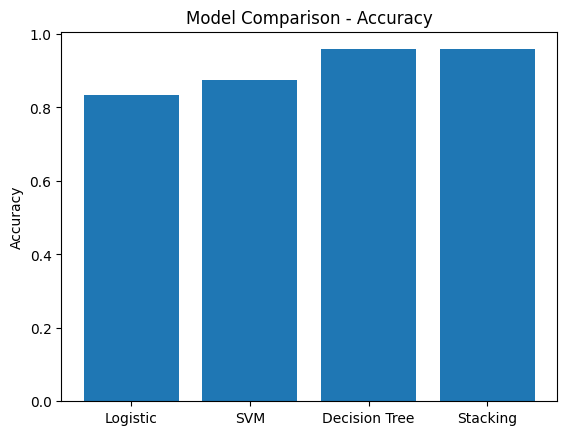

In [4]:
#POOVIKA M - 24BAD087
#EXP_9 - SCENARIO_4

print("POOVIKA M - 24BAD087\n")
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

#Load dataset
df = pd.read_csv("/content/sample_data/heart_stacking.csv")

#Check columns
print("Columns:\n", df.columns)

#Data Preprocessing

#Handle missing values (if any)
df.dropna(inplace=True)

# Encode categorical columns (if any)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

#Target column handling
#Common names in heart dataset
if "target" in df.columns:
    target_col = "target"
elif "HeartDisease" in df.columns:
    target_col = "HeartDisease"
elif "Outcome" in df.columns:
    target_col = "Outcome"
else:
    raise Exception("Target column not found")

#Features & target
X = df.drop(target_col, axis=1)
y = df[target_col]

#Feature Scaling (important for SVM)
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Base Models
lr = LogisticRegression()
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

#Train individual models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

#Predictions
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)
dt_pred = dt.predict(X_test)

#Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)
dt_acc = accuracy_score(y_test, dt_pred)

#Stacking Model
estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

#Print Results
print("\nLogistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Stacking Accuracy:", stack_acc)

#Visualization - Model Comparison
models = ["Logistic", "SVM", "Decision Tree", "Stacking"]
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]

plt.bar(models, accuracies)
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.show()

**SCENARIO 5**

**CODE INTERPRETATION**
1. Import Libraries

     Libraries are imported for:

    => Data handling (pandas)\
    => Model building (Random Forest)\
    => Evaluation (accuracy, precision-recall, AUC)\
    => Handling imbalance (SMOTE)\
    => Visualization (matplotlib)

2. Load Dataset

    The fraud dataset is loaded using:

    => read_csv()

    Column names are checked using:

    => columns

3. Select Features & Target

    Input features:

    => Transaction Amount, Time, PCA features

    Target variable:

    => Fraud (0 = Normal, 1 = Fraud)

4. Check Class Imbalance

    => Class distribution is printed using value_counts()\
    => Bar graph is plotted to visualize imbalance

5. Train-Test Split

    Dataset is divided into:

    => 80% training data\
    => 20% testing data

6. Train Model Before SMOTE

    => Random Forest model is trained on original data\
    => Predictions and probabilities are generated\
    => Accuracy is calculated

7. Apply SMOTE

    => SMOTE is applied to training data\
    => Minority class samples are increased\
    => Balanced dataset is created

8. Train Model After SMOTE

    => Random Forest model is trained on balanced data\
    => Predictions and probabilities are generated\
    => Accuracy is calculated

9. Compare Performance

    => Accuracy before and after SMOTE is compared\
    => Improvement in detecting fraud is analyzed

10. Visualization

    => Class distribution before SMOTE\
    => Class distribution after SMOTE\
    => Precision-Recall curve comparison

**CONCLUSION**

The program applies SMOTE to handle class imbalance in fraud detection. It improves model performance by increasing minority class samples. The results show better detection of fraud cases after applying SMOTE.

POOVIKA M - 24BAD087

Columns:
 Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')

Class Distribution BEFORE SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64


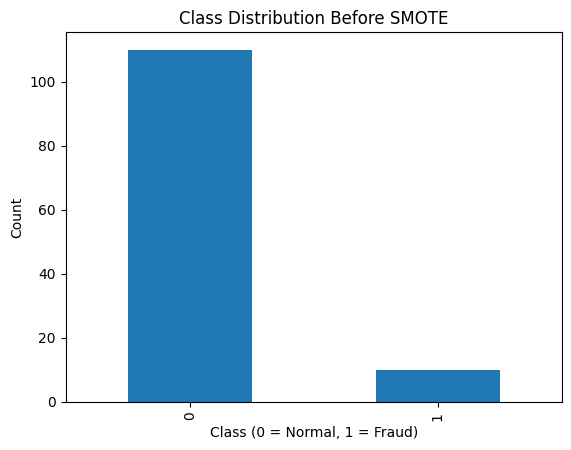


Class Distribution AFTER SMOTE:
Fraud
0    88
1    88
Name: count, dtype: int64


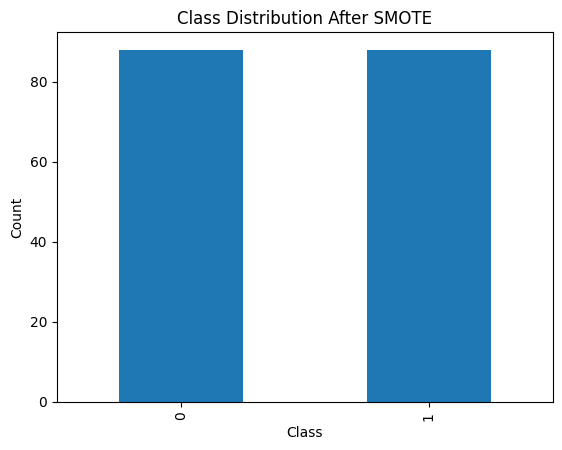


Accuracy BEFORE SMOTE: 0.9166666666666666
Accuracy AFTER SMOTE: 0.8333333333333334


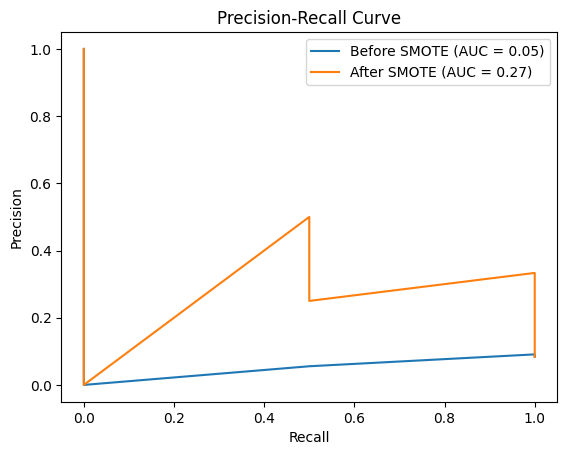

In [5]:
#POOVIKA M - 24BAD087
#EXP_9 - SCENARIO_5

print("POOVIKA M - 24BAD087\n")
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_curve, auc

from imblearn.over_sampling import SMOTE

#Load dataset
df = pd.read_csv("/content/sample_data/fraud_smote.csv")

#Check columns
print("Columns:\n", df.columns)

#Features & Target
target_col = "Fraud"

X = df.drop(target_col, axis=1)
y = df[target_col]

#Check Class Imbalance
print("\nClass Distribution BEFORE SMOTE:")
print(y.value_counts())

#Plot BEFORE SMOTE
y.value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model BEFORE SMOTE
model_before = RandomForestClassifier(random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:, 1]

acc_before = accuracy_score(y_test, y_pred_before)

#Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass Distribution AFTER SMOTE:")
print(pd.Series(y_train_sm).value_counts())

#Plot AFTER SMOTE
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#Model AFTER SMOTE
model_after = RandomForestClassifier(random_state=42)
model_after.fit(X_train_sm, y_train_sm)

y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:, 1]

acc_after = accuracy_score(y_test, y_pred_after)

#Print Accuracy
print("\nAccuracy BEFORE SMOTE:", acc_before)
print("Accuracy AFTER SMOTE:", acc_after)

#Precision-Recall Curve
prec_before, rec_before, _ = precision_recall_curve(y_test, y_prob_before)
prec_after, rec_after, _ = precision_recall_curve(y_test, y_prob_after)

pr_auc_before = auc(rec_before, prec_before)
pr_auc_after = auc(rec_after, prec_after)

plt.plot(rec_before, prec_before, label="Before SMOTE (AUC = %0.2f)" % pr_auc_before)
plt.plot(rec_after, prec_after, label="After SMOTE (AUC = %0.2f)" % pr_auc_after)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()